In [1]:
!pip install arch 
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.9/987.9 kB 17.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 10.4 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15548 sha256=5a3aa7c342c45b585ca1bcce9d9e3cc3fed5354ef4013914639f13b0f1de07e7
  Stored in directory: /root/.cache/pip/wheels/e9/25/85/25d2e1cfc0ece64b930b16972f7e4cc3599c43b531f1eba06d
Successfully built multitasking
  Attempting uninstall: websockets
    Found existing installation: websockets 12.0
    Uninstalling websockets-12.0:
      Successfully uninstalled websockets-12.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import t as student_t


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [3]:
ticker = "AMZN"
data = yf.download(ticker, start="2015-01-01", end="2024-01-01", progress=False, auto_adjust=True)
# auto_adjust=True returns prices already adjusted (this acts like 'Adj Close')
data = data.sort_index()
data.head()
# compute log returns (decimal)
data['logret'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()
returns = data['logret']

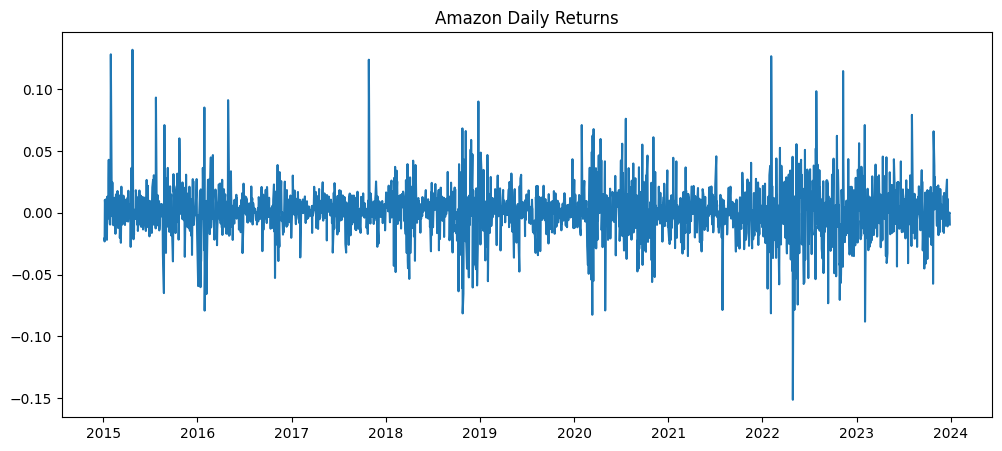

In [4]:
plt.figure(figsize=(12,5))

plt.plot(returns)

plt.title("Amazon Daily Returns")
plt.show()

In [5]:
model = arch_model(
    returns * 100,
    vol='GARCH',
    p=1,
    q=1,
    dist='t'
)

results = model.fit()

print(results.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 13001.832985685025
Iteration:      2,   Func. Count:     16,   Neg. LLF: 7234.01032962612
Iteration:      3,   Func. Count:     24,   Neg. LLF: 6552.168380145629
Iteration:      4,   Func. Count:     31,   Neg. LLF: 4542.689865506428
Iteration:      5,   Func. Count:     38,   Neg. LLF: 4515.494038661196
Iteration:      6,   Func. Count:     44,   Neg. LLF: 5196.162849910712
Iteration:      7,   Func. Count:     51,   Neg. LLF: 6842.894904341355
Iteration:      8,   Func. Count:     59,   Neg. LLF: 4517.706357842599
Iteration:      9,   Func. Count:     66,   Neg. LLF: 5144.554144368493
Iteration:     10,   Func. Count:     73,   Neg. LLF: 4513.235785165551
Iteration:     11,   Func. Count:     79,   Neg. LLF: 4513.226349584502
Iteration:     12,   Func. Count:     85,   Neg. LLF: 4513.226276406243
Iteration:     13,   Func. Count:     91,   Neg. LLF: 4513.226275553136
Optimization terminated successfully    (Exit mode 0)
          

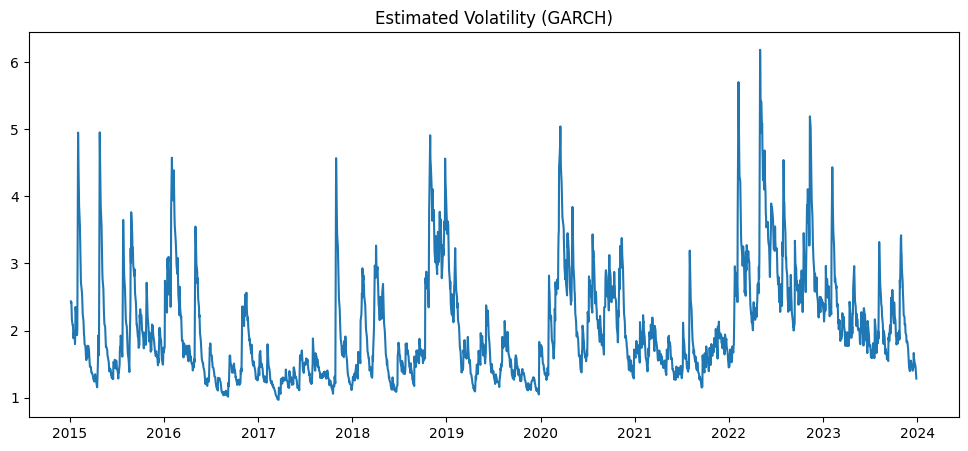

In [6]:
plt.figure(figsize=(12,5))

plt.plot(results.conditional_volatility)

plt.title("Estimated Volatility (GARCH)")
plt.show()

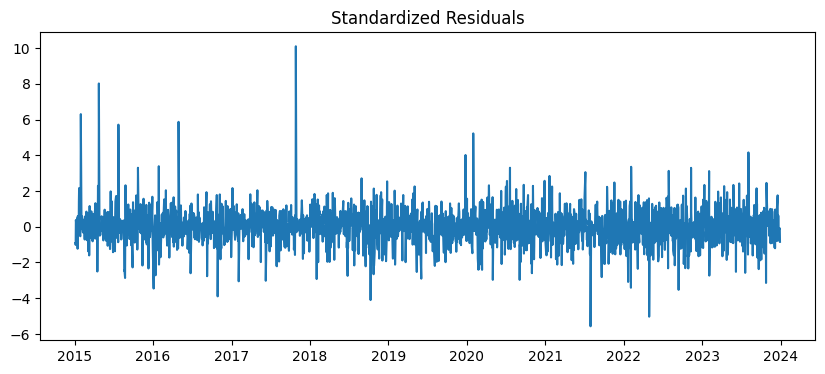

In [7]:
std_resid = results.std_resid

plt.figure(figsize=(10,4))
plt.plot(std_resid)
plt.title("Standardized Residuals")
plt.show()

In [8]:
ljung = acorr_ljungbox(std_resid, lags=[10], return_df=True)

print(ljung)

#p-value > 0.05 means no remaining autocorrelation.

     lb_stat  lb_pvalue
10  5.509146   0.854681


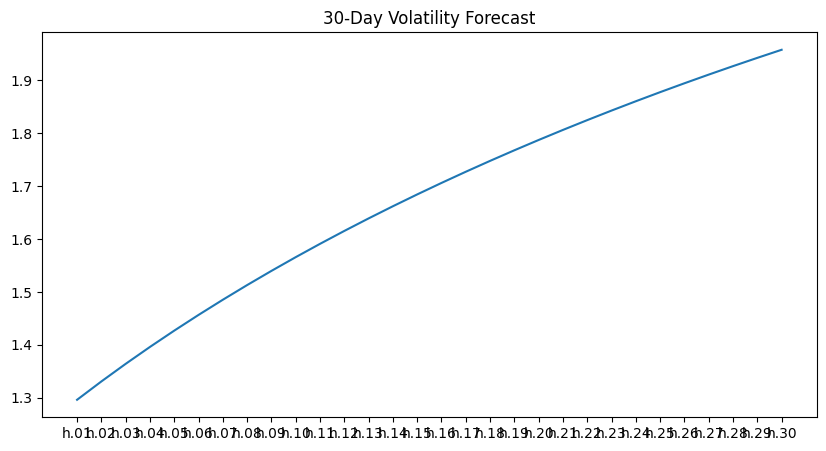

In [9]:
forecast = results.forecast(horizon=30)

vol_forecast = np.sqrt(forecast.variance.iloc[-1])

plt.figure(figsize=(10,5))

plt.plot(vol_forecast)

plt.title("30-Day Volatility Forecast")
plt.show()

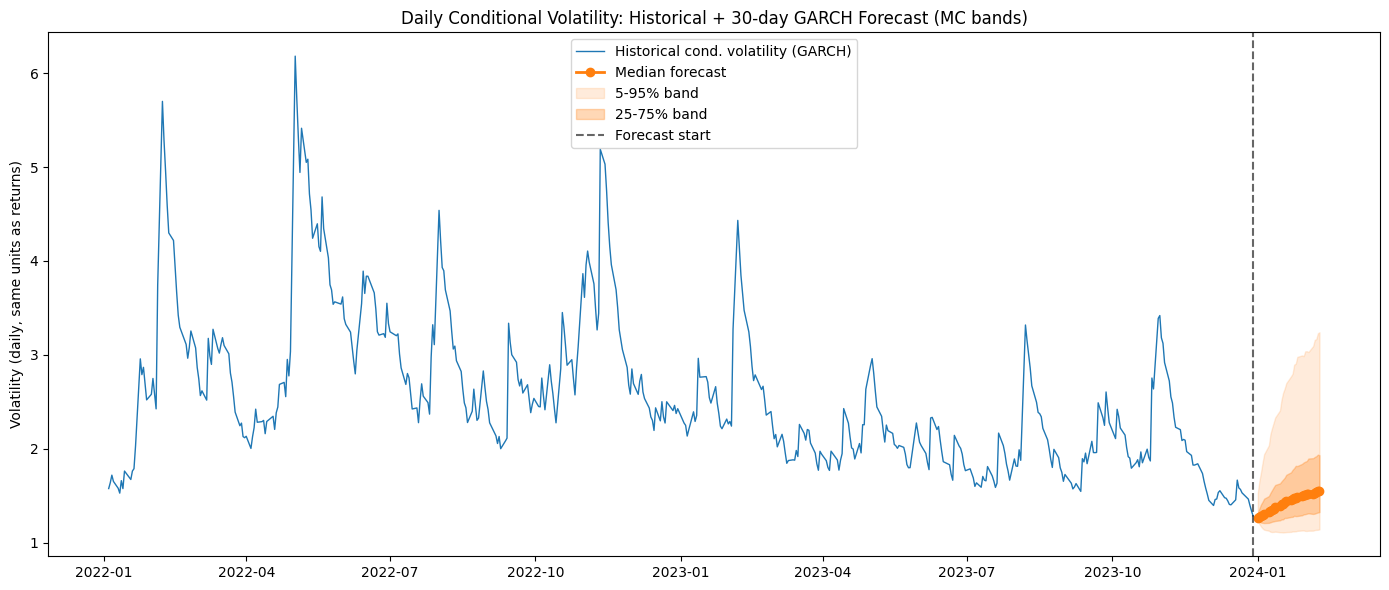

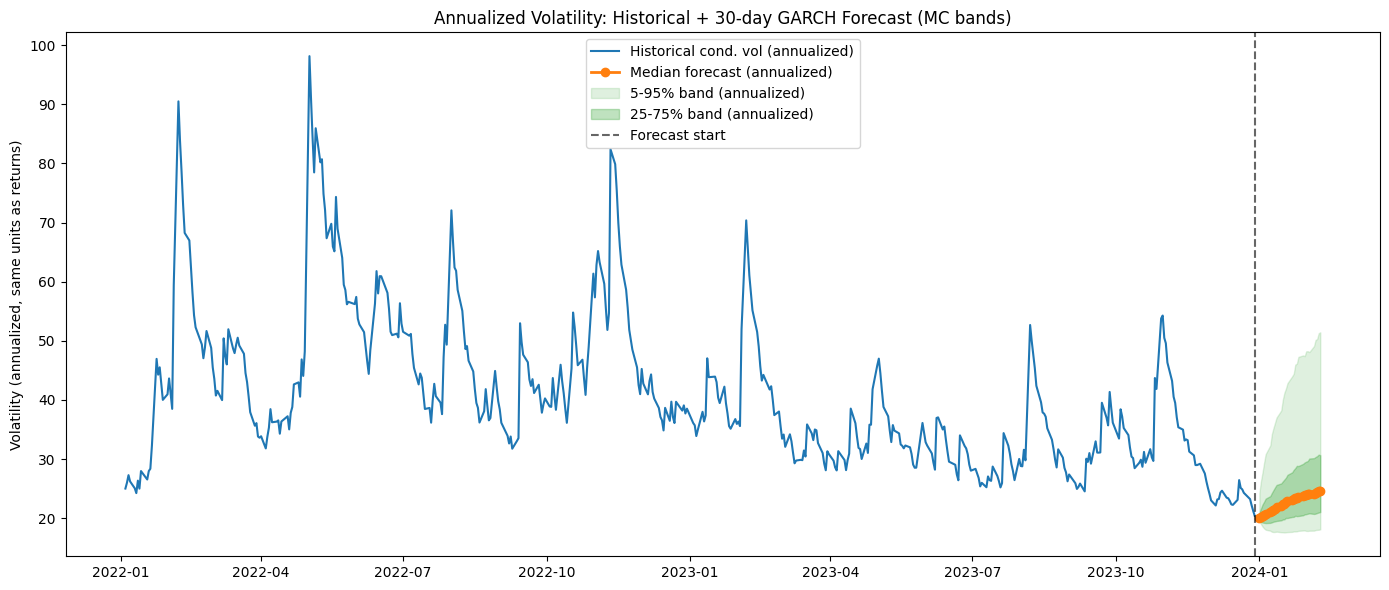

,vol_p05,vol_p25,vol_p50,vol_p75,vol_p95,vol_median_annualized,vol_p05_annualized,vol_p95_annualized
2024-01-01,1.236434,1.241665,1.260603,1.314779,1.532180,20.011459,19.627777,24.322608
2024-01-02,1.198307,1.222852,1.268273,1.363331,1.656777,20.133207,19.022533,26.300521
2024-01-03,1.171355,1.214059,1.283653,1.405926,1.748187,20.377354,18.594679,27.751611
2024-01-04,1.151522,1.210603,1.295530,1.434875,1.850752,20.565895,18.279847,29.379777
2024-01-05,1.137823,1.208303,1.306149,1.468246,1.942257,20.734470,18.062386,30.832372
2024-01-08,1.126623,1.210463,1.321767,1.496008,2.036581,20.982400,17.884592,32.329728
2024-01-09,1.115834,1.216345,1.336486,1.529380,2.157692,21.216062,17.713322,34.252294
2024-01-10,1.113031,1.222704,1.352860,1.558782,2.220036,21.475988,17.668817,35.241979
2024-01-11,1.114251,1.226445,1.359303,1.587720,2.276260,21.578263,17.688180,36.134499
2024-01-12,1.116712,1.230785,1.375779,1.614213,2.332833,21.839809,17.727248,37.032579


... (total 30 forecast days)
Median annualized volatility start: 20.011
Median annualized volatility end  : 24.663


In [10]:
# Monte Carlo simulation for volatility forecast uncertainty (use after results=model.fit() and forecast computed)
def _get_param(params, startswith):
    """Find first parameter whose name contains startswith (robust to different naming)."""
    for k in params.index:
        if startswith in k:
            return params[k]
    raise KeyError(f"No parameter containing '{startswith}' found in params: {list(params.index)}")

# --- parameters & data from your current workspace ---
horizon = 30
n_sims = 3000          # increase for smoother bands (3000 is a good tradeoff)
rng = np.random.default_rng(seed=2026)

# get last in-sample variance (h_t) from fitted results
last_var = float(results.conditional_volatility.iloc[-1])**2

# extract GARCH(1,1) core params robustly (omega, alpha1, beta1)
params = results.params

try:
    omega = float(_get_param(params, 'omega'))
    alpha = float(_get_param(params, 'alpha[1]')) if any('alpha' in k for k in params.index) else float(_get_param(params, 'alpha'))
    beta  = float(_get_param(params, 'beta[1]')) if any('beta' in k for k in params.index) else float(_get_param(params, 'beta'))
except Exception:
    # fallback: try common alternative names
    omega = float(params.get('omega', params.get('const', params.iloc[0])))
    alpha = float(params[[k for k in params.index if 'alpha' in k][0]])
    beta  = float(params[[k for k in params.index if 'beta' in k][0]])

# standardized residuals (empirical z)
std_resid = results.std_resid.dropna().values
if len(std_resid) < 50:
    raise ValueError("Too few standardized residuals to bootstrap from. Ensure results.std_resid is available and long enough.")

# Create simulations: draw z's by resampling (with replacement) from empirical standardized residuals
# We'll vectorize simulation: shape (n_sims, horizon)
z_draws = rng.choice(std_resid, size=(n_sims, horizon), replace=True)

# preallocate arrays for variances
vars_sim = np.zeros((n_sims, horizon))
# initialize with last in-sample variance
h_t = np.full(shape=(n_sims,), fill_value=last_var)

# recursive GARCH(1,1) propagation:
# h_{t+1} = omega + alpha * (z_t^2 * h_t) + beta * h_t
for t in range(horizon):
    # e_t^2 = z_t^2 * h_t
    zt = z_draws[:, t]
    h_next = omega + alpha * (zt**2 * h_t) + beta * h_t
    vars_sim[:, t] = h_next
    h_t = h_next  # move forward

# convert to vol (std dev) and compute percentiles
vol_sim = np.sqrt(vars_sim)               # daily vol units (same as results.conditional_volatility)
pctiles = [5, 25, 50, 75, 95]
vol_pct = np.percentile(vol_sim, pctiles, axis=0)  # shape (len(pctiles), horizon)

# Build forecast index (business days) aligned with your previous forecast plotting
last_date = returns.index[-1]
forecast_index = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=horizon)

vol_median = vol_pct[2, :]      # 50%
vol_p05 = vol_pct[0, :]
vol_p25 = vol_pct[1, :]
vol_p75 = vol_pct[3, :]
vol_p95 = vol_pct[4, :]

# Make DataFrame for easy display
forecast_mc_df = pd.DataFrame({
    'vol_p05': vol_p05,
    'vol_p25': vol_p25,
    'vol_p50': vol_median,
    'vol_p75': vol_p75,
    'vol_p95': vol_p95
}, index=forecast_index)

# --- Plot daily volatility forecast with bands ---
plt.figure(figsize=(14,6))
# historical volatility (last N days)
hist_days = 500
hist_vol = results.conditional_volatility
hist_plot = hist_vol.iloc[-hist_days:]

plt.plot(hist_plot.index, hist_plot, label='Historical cond. volatility (GARCH)', linewidth=1)
plt.plot(forecast_mc_df.index, forecast_mc_df['vol_p50'], label='Median forecast', linewidth=2, marker='o')
plt.fill_between(forecast_mc_df.index, forecast_mc_df['vol_p05'], forecast_mc_df['vol_p95'],
                 color='C1', alpha=0.15, label='5-95% band')
plt.fill_between(forecast_mc_df.index, forecast_mc_df['vol_p25'], forecast_mc_df['vol_p75'],
                 color='C1', alpha=0.3, label='25-75% band')

plt.axvline(last_date, color='k', linestyle='--', alpha=0.6, label='Forecast start')
plt.title('Daily Conditional Volatility: Historical + 30-day GARCH Forecast (MC bands)')
plt.ylabel('Volatility (daily, same units as returns)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Annualized version (common in finance) ---
annualize = np.sqrt(252)
plt.figure(figsize=(14,6))
plt.plot(hist_plot.index, hist_plot * annualize, label='Historical cond. vol (annualized)')
plt.plot(forecast_mc_df.index, forecast_mc_df['vol_p50'] * annualize, label='Median forecast (annualized)', linewidth=2, marker='o')
plt.fill_between(forecast_mc_df.index, forecast_mc_df['vol_p05'] * annualize, forecast_mc_df['vol_p95'] * annualize,
                 color='C2', alpha=0.15, label='5-95% band (annualized)')
plt.fill_between(forecast_mc_df.index, forecast_mc_df['vol_p25'] * annualize, forecast_mc_df['vol_p75'] * annualize,
                 color='C2', alpha=0.3, label='25-75% band (annualized)')

plt.axvline(last_date, color='k', linestyle='--', alpha=0.6, label='Forecast start')
plt.title('Annualized Volatility: Historical + 30-day GARCH Forecast (MC bands)')
plt.ylabel('Volatility (annualized, same units as returns)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Show numeric table for the forecast (daily + annualized) ---
out_df = forecast_mc_df.copy()
out_df['vol_median_annualized'] = out_df['vol_p50'] * annualize
out_df['vol_p05_annualized'] = out_df['vol_p05'] * annualize
out_df['vol_p95_annualized'] = out_df['vol_p95'] * annualize

display(out_df.round(6).head(10))
print("... (total {} forecast days)".format(len(out_df)))

# Quick summary of median annualized start & end
start_median_ann = out_df['vol_median_annualized'].iloc[0]
end_median_ann = out_df['vol_median_annualized'].iloc[-1]
print(f"Median annualized volatility start: {start_median_ann:.3f}")
print(f"Median annualized volatility end  : {end_median_ann:.3f}")

In [11]:
# --- Cell A: Value at Risk (VaR) using GARCH forecast ---
# Assumptions:
# - `results` is your fitted arch model result
# - `returns` is the pandas Series of returns used to fit the model (index = dates)
# - `data` contains the price series (Adj Close or Close). We'll try to detect a price column.

# Basic checks
if 'returns' not in globals():
    raise RuntimeError("Please ensure `returns` Series exists in the workspace (log returns used to fit the GARCH).")

# detect scale: if returns are in percent (typical when you do 100*log_ret), convert to decimal for VaR math
median_abs = returns.abs().median()
is_percent = median_abs > 1  # heuristic: median abs > 1 suggests values are in percent units
scale_note = "percent" if is_percent else "decimal"
print(f"Detected returns scale: {scale_note} (median abs = {median_abs:.6g})")

# Convert returns to decimal (for VaR calculation) but keep original for display if needed
returns_dec = returns / 100.0 if is_percent else returns.copy()

# 1) Get point variance forecast from results.forecast()
horizon = 30
forecast_obj = results.forecast(horizon=horizon, reindex=False)  # reindex False keeps integer horizons
# forecast.variance.iloc[-1] in your earlier code; here pick last available in-sample row if present
var_point = forecast_obj.variance.iloc[-1]  # series indexed by 1..horizon (or 0..horizon-1) depending on arch version

# If indexed 0..H-1 convert to 1..H for clarity
var_point.index = np.arange(1, len(var_point)+1)

# daily sigma (decimal)
sigma_daily = np.sqrt(var_point)

# get distribution details from results
params = results.params
dist_name = getattr(results.model, "dist", None)
print("Fitted distribution (arch model):", dist_name)

# determine t degrees of freedom if present in params or in model
df = None
if 'nu' in params.index:
    df = float(params['nu'])
elif any('nu' in str(k).lower() for k in params.index):
    # fallback
    for k in params.index:
        if 'nu' in k.lower():
            df = float(params[k]); break

# VaR levels
alpha = [0.01, 0.025, 0.05]  # 99%, 97.5%, 95% VaR
alpha_labels = {0.01: "VaR 99%", 0.025: "VaR 97.5%", 0.05: "VaR 95%"}

# Parametric VaR (normal) for 1..H
z_norm = {a: np.abs(np.quantile(np.random.normal(size=1000000), a)) for a in alpha}  # quick z approx
# Better: compute z from analytic quantile
import scipy.stats as st
z_norm = {a: st.norm.ppf(1-a) for a in alpha}  # since VaR is positive loss = z * sigma

# parametric with Student-t if df available
if df is not None:
    # t quantiles: student_t.ppf(1-alpha, df) rescales; but t variates have heavier tails and scale differs
    # For standard t with df, variance = df/(df-2) if df>2, so convert to std-normal equivalent scaling:
    t_q = {a: student_t.ppf(1-a, df) for a in alpha}
    t_scale = np.sqrt(df / (df - 2)) if df > 2 else None
else:
    t_q = None

# Build VaR DataFrame
var_df = pd.DataFrame({
    'sigma_daily': sigma_daily.values
}, index=sigma_daily.index)

for a in alpha:
    # normal VaR (decimal returns)
    var_df[f'VaR_norm_{int((1-a)*100)}'] = z_norm[a] * var_df['sigma_daily']
    # t-VaR if df available
    if t_q is not None:
        if t_scale is not None:
            # scale t quantile to match std-normal units
            var_df[f'VaR_t_{int((1-a)*100)}'] = (t_q[a] / t_scale) * var_df['sigma_daily']
        else:
            var_df[f'VaR_t_{int((1-a)*100)}'] = (t_q[a]) * var_df['sigma_daily']  # fallback

# convert to percent if original returns were percent
if is_percent:
    # var_df currently in decimal returns; convert to percent
    var_df_pct = var_df * 100.0
else:
    var_df_pct = var_df.copy()

# Display 1-day VaR (horizon=1 row)
display_label = "1-day VaR (first forecast day)"
print(display_label)
display(var_df_pct.iloc[0:5].round(6))  # show first few days

# Multi-day VaR naive aggregation (square-root-of-time) - note: this is approximate and ignores changing variance dynamics.
# More correct approach uses simulation (we provide this later). Here show naive aggregated VaR for horizons 1,5,10,20,30.
multi_horizons = [1,5,10,20,30]
multi_var = {}
for h in multi_horizons:
    # naive aggregation: sigma_multi = sqrt(sum of sigma^2) if independent (rough approx: sqrt(h) * sigma_1 if stationary)
    sigma_h = np.sqrt((var_df['sigma_daily'].iloc[:h]**2).sum()) if h <= len(var_df) else np.sqrt(var_df['sigma_daily'].iloc[:len(var_df)].pow(2).sum())
    multi_var[h] = { 'sigma_h': sigma_h }
    for a in alpha:
        multi_var[h][f'VaR_norm_{int((1-a)*100)}'] = z_norm[a] * sigma_h
        if t_q is not None and t_scale is not None:
            multi_var[h][f'VaR_t_{int((1-a)*100)}'] = (t_q[a] / t_scale) * sigma_h

multi_var_df = pd.DataFrame.from_dict({h: multi_var[h] for h in multi_var}, orient='index')
if is_percent:
    multi_var_df = multi_var_df * 100.0

print("\nNaive multi-day VaR summary (approx; for accurate multi-day VaR use simulation):")
display(multi_var_df.round(6))

# ----- Bootstrap / simulation VaR (nonparametric) for multi-day (uses residuals + GARCH recursion) -----
# We provide a function for an empirical Monte Carlo VaR which re-simulates returns and computes portfolio loss quantiles.
def simulate_returns_from_garch(n_sims=2000, horizon=10, parametric=False, dist='normal'):
    """
    Simulate n_sims horizon-day returns using:
    - parametric: draws from fitted distribution (normal or t with df)
    - nonparametric: resample standardized residuals from results.std_resid
    The GARCH recursion uses the fitted omega/alpha/beta params.
    Returns: simulated cumulative returns over horizon (decimal)
    """
    # extract params robustly
    p = results.params
    def _get(k):
        for key in p.index:
            if k in key:
                return float(p[key])
        # fallback
        return None

    # Extract omega, alpha1, beta1 (adaptable if named differently)
    try:
        omega = _get('omega') if _get('omega') is not None else _get('const')
        alpha = _get('alpha[1]') if _get('alpha[1]') is not None else _get('alpha')
        beta  = _get('beta[1]') if _get('beta[1]') is not None else _get('beta')
    except Exception:
        # Try more direct indexing when arch names are unusual
        omega = float(p.iloc[0])
        alpha = float(p[[i for i in p.index if 'alpha' in i][0]])
        beta  = float(p[[i for i in p.index if 'beta' in i][0]])

    # last in-sample variance:
    h0 = float(results.conditional_volatility.iloc[-1])**2

    # standardized residuals
    std_res = results.std_resid.dropna().values
    if len(std_res) < 50:
        raise RuntimeError("Too few residuals for bootstrap. Increase sample or use parametric=True.")

    rng = np.random.default_rng(12345)
    cumrets = np.zeros(n_sims)
    for s in range(n_sims):
        h_t = h0
        r_path = []
        for t in range(horizon):
            if parametric:
                if dist == 't' and df is not None:
                    z = student_t.rvs(df, random_state=rng)
                    # scale to unit variance: student_t has var=df/(df-2) -> scale
                    if df > 2:
                        z = z / np.sqrt(df/(df-2))
                else:
                    z = rng.standard_normal()
            else:
                z = rng.choice(std_res)
            eps = z * np.sqrt(h_t)  # return innovation (decimal units)
            r_path.append(eps)
            # Update variance by GARCH(1,1)
            h_t = omega + alpha * (eps**2) + beta * h_t
        # cumulative return over horizon (sum of returns)
        cumrets[s] = np.sum(r_path)
    return cumrets

# Example: compute 10-day VaR via bootstrap and parametric
sim_h = 10
n_sims = 3000
print("\nSimulating to compute empirical VaR (this may take a few seconds)...")
# nonparametric bootstrap
sim_nonparam = simulate_returns_from_garch(n_sims=n_sims, horizon=sim_h, parametric=False)
# parametric t (if df available) else normal
sim_param = simulate_returns_from_garch(n_sims=n_sims, horizon=sim_h, parametric=True, dist='t' if df is not None else 'normal')

# compute quantiles (loss positive)
q_levels = [0.01, 0.025, 0.05]
emp_var_nonparam = {f'VaR_{int((1-q)*100)}': -np.quantile(sim_nonparam, q) for q in q_levels}
emp_var_param    = {f'VaR_{int((1-q)*100)}': -np.quantile(sim_param, q) for q in q_levels}

# convert to percent if original returns were percent
if is_percent:
    emp_var_nonparam = {k: 100*v for k,v in emp_var_nonparam.items()}
    emp_var_param = {k: 100*v for k,v in emp_var_param.items()}

print(f"\nEmpirical {sim_h}-day VaR (nonparametric bootstrap):")
print(emp_var_nonparam)
print(f"\nParametric {sim_h}-day VaR (via GARCH param draws):")
print(emp_var_param)

# Final note display
print("\nNotes:")
print("- Parametric VaR uses analytic quantiles multiplied by forecast sigma (fast).")
print("- Multi-day naive VaR uses sqrt-sum approximation; for accurate multi-day VaR use the simulation above.")
print("- If your returns were in percent units, the outputs above are returned in percent units.")

Detected returns scale: decimal (median abs = 0.00993934)
Fitted distribution (arch model): None
1-day VaR (first forecast day)


,sigma_daily,VaR_norm_99,VaR_t_99,VaR_norm_97,VaR_t_97,VaR_norm_95,VaR_t_95
1,1.296297,3.015638,3.413758,2.540696,2.565358,2.132219,1.988615
2,1.330941,3.096232,3.504993,2.608597,2.633918,2.189204,2.041762
3,1.364206,3.173617,3.592593,2.673794,2.699748,2.243918,2.092791
4,1.396196,3.248038,3.676839,2.736494,2.763057,2.296538,2.141867
5,1.427005,3.319711,3.757974,2.796879,2.824028,2.347215,2.189131



Naive multi-day VaR summary (approx; for accurate multi-day VaR use simulation):


,sigma_h,VaR_norm_99,VaR_t_99,VaR_norm_97,VaR_t_97,VaR_norm_95,VaR_t_95
1,1.296297,3.015638,3.413758,2.540696,2.565358,2.132219,1.988615
5,3.049353,7.093856,8.030377,5.976622,6.034637,5.015740,4.677932
10,4.554117,10.594460,11.993126,8.925905,9.012547,7.490855,6.986349
20,7.031257,16.357149,18.516597,13.781010,13.914781,11.565388,10.786464
30,9.218394,21.445192,24.276356,18.067721,18.243102,15.162909,14.141693



Simulating to compute empirical VaR (this may take a few seconds)...

Empirical 10-day VaR (nonparametric bootstrap):
{'VaR_99': 11.63374701356276, 'VaR_97': 9.156243080575718, 'VaR_95': 7.278706665250092}

Parametric 10-day VaR (via GARCH param draws):
{'VaR_99': 11.65493808548466, 'VaR_97': 9.07446137163215, 'VaR_95': 7.284305464154319}

Notes:
- Parametric VaR uses analytic quantiles multiplied by forecast sigma (fast).
- Multi-day naive VaR uses sqrt-sum approximation; for accurate multi-day VaR use the simulation above.
- If your returns were in percent units, the outputs above are returned in percent units.


Using price column 'Close', last observed price S0 = 151.94
Detected model conditional volatility mean = 2.024. Assuming model uses percent units: True


/tmp/ipykernel_18/3684472628.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data[price_col].dropna().iloc[-1])  # last observed price (use iloc to avoid FutureWarning)


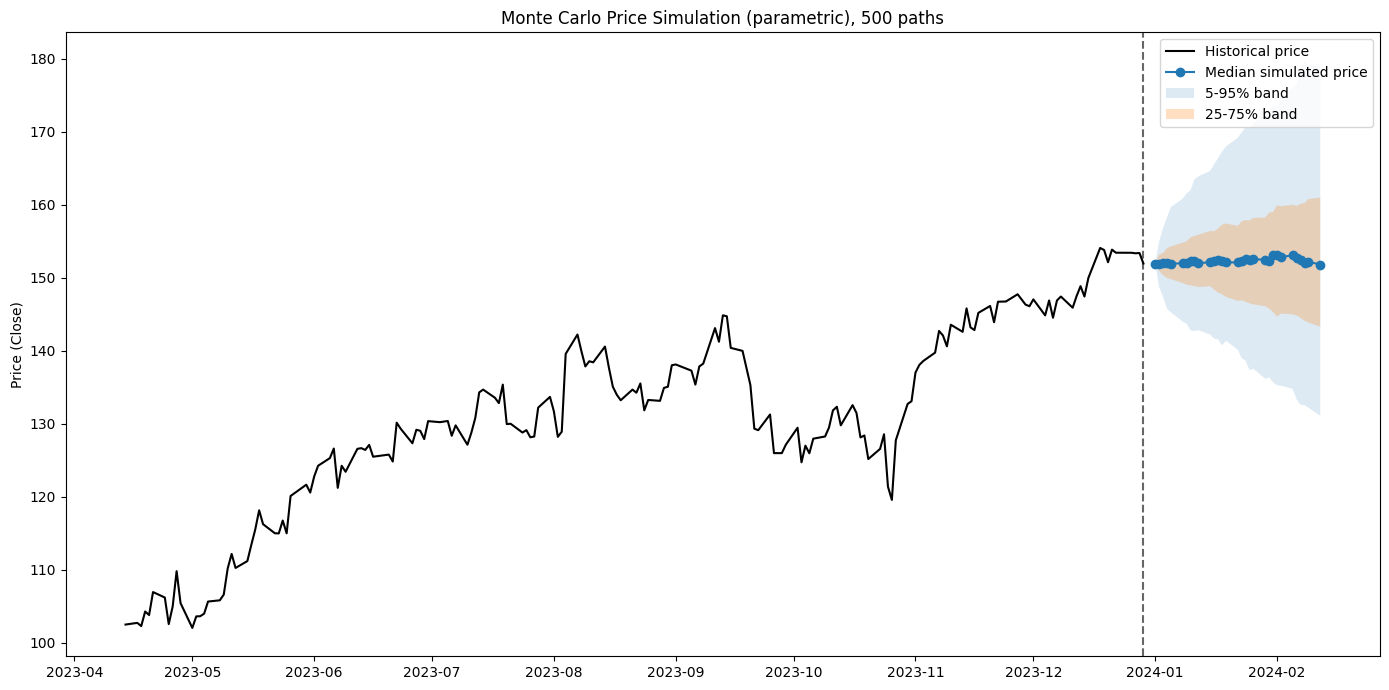

,q05,q25,q50,q75,q95
2024-01-01,151.9400,151.9400,151.9400,151.9400,151.9400
2024-01-02,148.7191,150.9139,151.8344,153.1620,154.9254
2024-01-03,147.4000,150.3577,152.0025,153.3927,156.7875
2024-01-04,145.7349,149.9554,152.0218,154.0348,158.2701
2024-01-05,145.2612,149.8024,151.8944,154.2907,159.6860
2024-01-08,143.9899,149.2739,151.9998,154.8027,160.8109
2024-01-09,143.6985,149.0349,152.0374,154.9862,161.5304
2024-01-10,142.7804,148.9527,152.3198,155.5185,161.9947
2024-01-11,142.7033,148.8365,152.2617,155.7240,163.4880
2024-01-12,142.8007,148.7259,151.9694,155.8874,163.8873


Saved garch_price_simulation_30d_fixed.csv


In [12]:
# --- Corrected Cell B: Monte Carlo price path simulation using GARCH dynamics (robust units handling) ---
# Preconditions:
# - `data` dataframe holds the price series used to compute returns (Adj Close / Close)
# - `results` is the fitted arch results (GARCH fit)
# - `returns` is the returns Series used to fit the model (index aligned with data)

# ---- detect price column robustly ----
price_col_candidates = [c for c in ['Adj Close', 'Adj_Close', 'Close', 'PRICE', 'close'] if c in data.columns]
if not price_col_candidates:
    numeric_cols = data.select_dtypes("number").columns.tolist()
    price_col = numeric_cols[-1] if numeric_cols else None
else:
    price_col = price_col_candidates[0]

if price_col is None:
    raise RuntimeError("Could not detect a price column in `data`. Ensure data contains Adj Close/Close.")

S0 = float(data[price_col].dropna().iloc[-1])  # last observed price (use iloc to avoid FutureWarning)
print(f"Using price column '{price_col}', last observed price S0 = {S0:.2f}")

# ---- simulation parameters ----
n_paths = 500      # number of MC paths to draw
horizon = 30       # days
rng = np.random.default_rng(2026)
sim_method = 'parametric'  # 'parametric' or 'bootstrap'

# ---- extract model params (keep them in the same units the model was fitted) ----
p = results.params

def _get_param(p, name):
    for key in p.index:
        if name in key:
            return float(p[key])
    return None

omega = _get_param(p, 'omega') or _get_param(p, 'const') or float(p.iloc[0])
alpha = _get_param(p, 'alpha[1]') or _get_param(p,'alpha') 
beta  = _get_param(p, 'beta[1]') or _get_param(p,'beta')

if alpha is None or beta is None:
    alpha = float(p[[k for k in p.index if 'alpha' in k][0]])
    beta  = float(p[[k for k in p.index if 'beta' in k][0]])

# ---- conditional volatility scale detection ----
cond_vol = results.conditional_volatility.dropna()
cond_mean = float(cond_vol.mean())
# If the model's conditional_volatility average is > 1, we assume the model was fitted on percent returns (e.g. 1.5 -> 1.5%)
# Otherwise assume decimal returns (e.g. 0.015 -> 1.5%)
model_uses_percent = cond_mean > 1.0
print(f"Detected model conditional volatility mean = {cond_mean:.4g}. Assuming model uses percent units: {model_uses_percent}")

# h0 in model units (same units as results.params)
h0 = float(cond_vol.iloc[-1])**2

# standardized residuals and t df if present
std_res = results.std_resid.dropna().values
df = None
for k in p.index:
    if 'nu' in k.lower() or 'df' in k.lower():
        try:
            df = float(p[k]); break
        except Exception:
            pass

# ---- simulation storage ----
paths = np.zeros((n_paths, horizon+1))
paths[:, 0] = S0

# Simulate
for i in range(n_paths):
    h_t = h0
    logS = np.log(S0)
    for t in range(horizon):
        # draw standardized shock z (unit variance)
        if sim_method == 'parametric':
            if df is not None:
                z = student_t.rvs(df)
                if df > 2:
                    z = z / np.sqrt(df/(df-2))   # scale to unit variance
            else:
                z = rng.standard_normal()
        else:
            # bootstrap residual
            z = rng.choice(std_res)

        # innovation in model units (same as returns used in fitting)
        eps_model_units = z * np.sqrt(h_t)   # e_t in model units (percent or decimal depending on fit)
        
        # convert innovation to decimal returns for price update:
        # if model uses percent, convert: percent -> decimal by dividing by 100
        if model_uses_percent:
            r_decimal = eps_model_units / 100.0
        else:
            r_decimal = eps_model_units

        # update log price with decimal return
        logS = logS + r_decimal
        paths[i, t+1] = np.exp(logS)

        # update variance using GARCH recursion in model units (eps squared in model units)
        h_t = omega + alpha * (eps_model_units**2) + beta * h_t

# ---- build quantiles and DataFrame ----
dates = pd.bdate_range(start=returns.index[-1] + pd.Timedelta(days=1), periods=horizon+1)
q5  = np.percentile(paths, 5, axis=0)
q25 = np.percentile(paths, 25, axis=0)
q50 = np.percentile(paths, 50, axis=0)
q75 = np.percentile(paths, 75, axis=0)
q95 = np.percentile(paths, 95, axis=0)

sim_df = pd.DataFrame({
    'q05': q5, 'q25': q25, 'q50': q50, 'q75': q75, 'q95': q95
}, index=dates)

# ---- plot ----
plt.figure(figsize=(14,7))
hist_days = 180
hist_prices = data[price_col].dropna().iloc[-hist_days:]
plt.plot(hist_prices.index, hist_prices.values, label='Historical price', color='black')
plt.plot(sim_df.index, sim_df['q50'], label='Median simulated price', marker='o')
plt.fill_between(sim_df.index, sim_df['q05'], sim_df['q95'], alpha=0.15, label='5-95% band')
plt.fill_between(sim_df.index, sim_df['q25'], sim_df['q75'], alpha=0.25, label='25-75% band')
plt.axvline(returns.index[-1], color='k', linestyle='--', alpha=0.6)
plt.legend()
plt.title(f"Monte Carlo Price Simulation ({sim_method}), {n_paths} paths")
plt.ylabel(f"Price ({price_col})")
plt.tight_layout()
plt.show()

# ---- output and save ----
display(sim_df.head(10).round(4))
sim_df.to_csv("garch_price_simulation_30d_fixed.csv")
print("Saved garch_price_simulation_30d_fixed.csv")

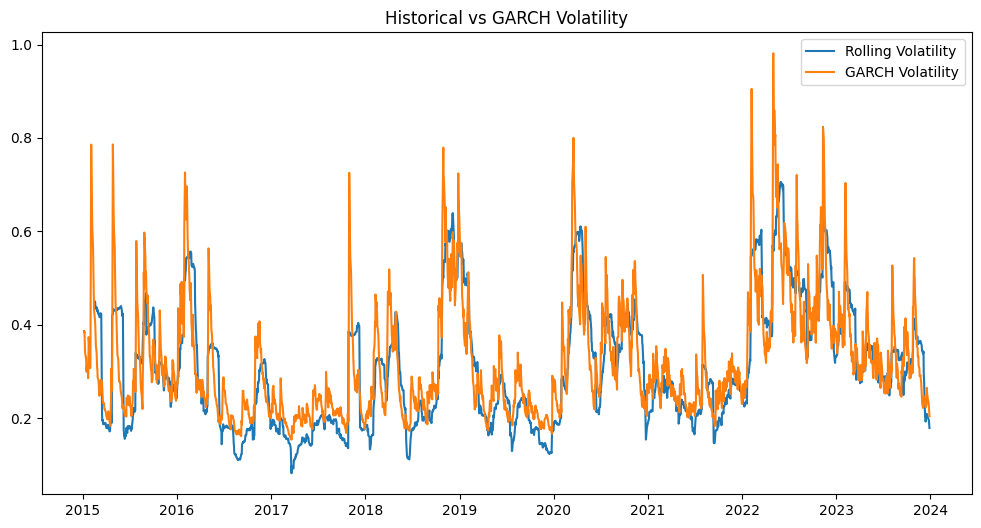

In [13]:
rolling_vol = returns.rolling(30).std() * np.sqrt(252)

garch_vol = results.conditional_volatility * np.sqrt(252) / 100

plt.figure(figsize=(12,6))

plt.plot(rolling_vol, label="Rolling Volatility")
plt.plot(garch_vol, label="GARCH Volatility")

plt.legend()
plt.title("Historical vs GARCH Volatility")

plt.show()

Blue lines is the realized volatility, computed directly from the returns, 30/day window, and annualized.

Orange lines represents E[σt​∣past information] = the expected volatility given the past shocks. GARCH produces a smoothed estimate of volatility.

We can also see three important events: 
1. 2018 - spike in volatility.
2. 2020 - COVID shock.
3. 2022 - Inflation / rate hikes.


> volatility is predictablereturns are not


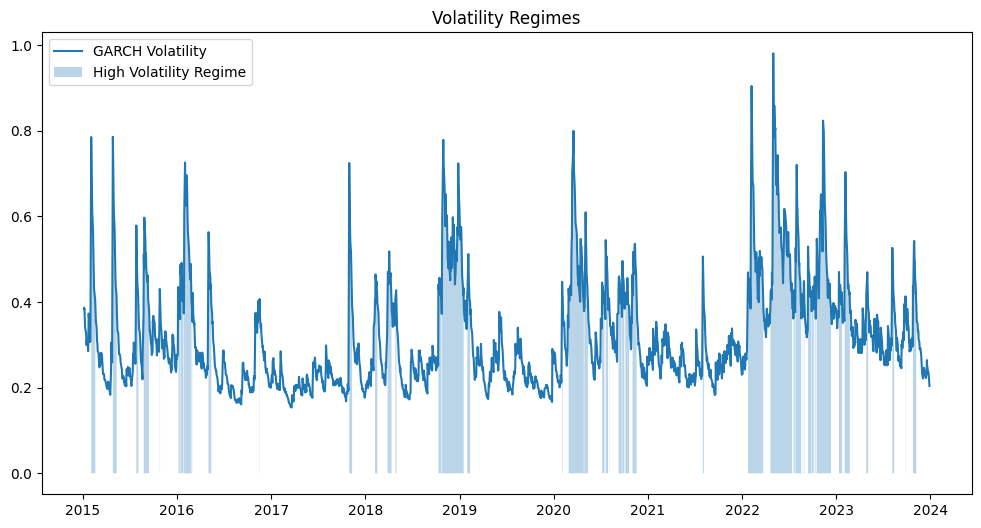

In [14]:
high_vol = garch_vol > garch_vol.quantile(0.75)

plt.figure(figsize=(12,6))
plt.plot(garch_vol, label="GARCH Volatility")
plt.fill_between(garch_vol.index, garch_vol, where=high_vol, alpha=0.3, label="High Volatility Regime")

plt.legend()
plt.title("Volatility Regimes")
plt.show()

This analysis shows that volatility in financial time series is not constant over time, 
but rather clusters in periods of high and low variability.

Key findings:
- Volatility is time-dependent and exhibits clustering behavior.
- Periods of high volatility tend to persist, increasing risk exposure.
- Traditional models assuming constant variance may underestimate risk.

Business implications:
- Risk management should adapt dynamically to changing volatility conditions.
- During high-volatility periods, institutions may consider:
    - reducing exposure
    - increasing capital buffers
    - adjusting pricing strategies
- Volatility forecasts can improve decision-making in trading, hedging, and portfolio allocation.

Conclusion:
Incorporating volatility modeling (e.g., GARCH) provides a more realistic representation 
of financial risk and enables better-informed strategic decisions.